# 🧠 Modelo de predição de funcionários com risco de burnout  

Global Solution - O Futuro do Trabalho: Mais Humano, Inclusivo e Sustentável  

**Eixo Temático:** Monitoramento de bem-estar e saúde mental no trabalho.  

**Este notebook é um protótipo de um sistema de análise de risco de burnout em funcionários de uma empresa com base em dados coletados no ambiente de trabalho.**  

# 1 . Dados

Para a demonstração dessa prova de conceito, usamos dados sintéticos.

## Importação (coleta)

O _dataset_ foi salvo em nuvem para conveniência no Google Colab, pois a máquina virtual do Colab limpa todos os _uploads_ quando o _runtime_ cai.

In [ ]:
# Importações das ferramentas necessárias para manejo dos dados
import pandas as pd

# Criação do DataFrame base para todo o projeto
df = pd.read_csv("https://docs.google.com/spreadsheets/d/1yxeQAFP4WsPyx5FUZjFXVRG03M1sRiT1YM8RUACQmzk/export?format=csv")

# Verificação se a importação foi bem sucedida
# e uma primeira olhada aparência dos dados
df.head()

,senioridade,idade,horas_trabalho,pct_reunioes,interacoes_noturnas,periodo_sem_ferias,score_satisfacao,burnout_label
0,Junior,25,48,0.44,5,12,5,0
1,Junior,20,41,0.48,2,7,4,0
2,Senior,31,47,0.24,7,26,5,0
3,Junior,36,47,0.53,3,14,3,0
4,Junior,31,44,0.27,1,7,3,0


## Descrição das variáveis

O _dataset_ contém 5000 amostras.

As variáveis são:
* **Senioridade**: `senioridade` Catergórica

  Nível de carreira.
  
* **Idade**: `idade` Inteiro (20 à 60)
  
  Idade do funcionário.

* **Jornada**: `horas_trabalho` Inteiro (35 à 60)

  Horas totais trabalhadas na semana.

* **Reuniões**: `pct_reunioes` Decimal (0.1 à 0.6)

  Proporção do tempo de trabalho gasto em reuniões.

* **Atividade fora do expediente**: `interacoes_noturnas` Inteiro (0 à 20)

  Quantidade de eventos de atividades de trabalho fora de expediente, como acesso a sistemas, envio de e-mails e status de disponibilidade em chat corporativo.

* **Férias**: `periodo_sem_ferias` Inteiro (0 à 36)

  Quantos meses desde as últimas férias.

* **Satisfação**: `score_satisfacao` Inteiro (1 à 5)

  Índice de satisfação com o "clima" interno, declarado pelo funcionário.

* **Burnout**: `burnout_label` Inteiro (0 ou 1)

  1 para ocorrência de burnout e 0 para não ocorrência.

## Análise Exploratória de Dados (EDA) 📊

**Antes de tudo, é importante ressaltar que toda a exploração dos dados feita nesse _notebook_ pode ser feita de forma equivalente com exatamente o mesmo resultado utilizando R.**

Como o problema em questão é uma **classificação binária**, ou seja, a variável _target_ só tem dois _labels_: sim ou não, 1 ou 0, vamos iniciar a exploração vendo a frequência de ocorrência de _burnout_.

### Distribuições:

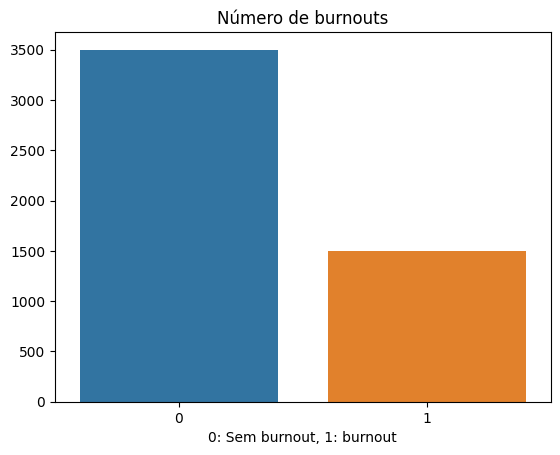

Número de funcionários sem burnout: 3499 (69.98%), com burnout: 1501 (30.02%)


In [ ]:
# Importação das duas bibliotecas fundamentais para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Criação do plot da frequência de incidencia de burnout
sns.countplot(
    x='burnout_label',
    data=df,
    hue='burnout_label',
    legend=None)
plt.title('Número de burnouts') # Título
plt.xlabel('0: Sem burnout, 1: burnout') # Legenda
plt.ylabel('')
plt.show()

burnout_amount = df['burnout_label'].value_counts() # Frequência de sem burnout e com burnout
burnout_percentage = burnout_amount / len(df) * 100 # Criação das porcentagens das frequências
print(f"Número de funcionários sem burnout: {burnout_amount[0]} ({burnout_percentage[0]:.2f}%), com burnout: {burnout_amount[1]} ({burnout_percentage[1]:.2f}%)")

O número de funcionários com _burnout_ não é próximo dos sem _burnout_, então a acurácia não será uma métrica muito boa de avaliação dos modelos preditivos.

Agora, vamo ver a distribuição das _features_ para os casos de _burnout_ e sem, começando por senioridade.

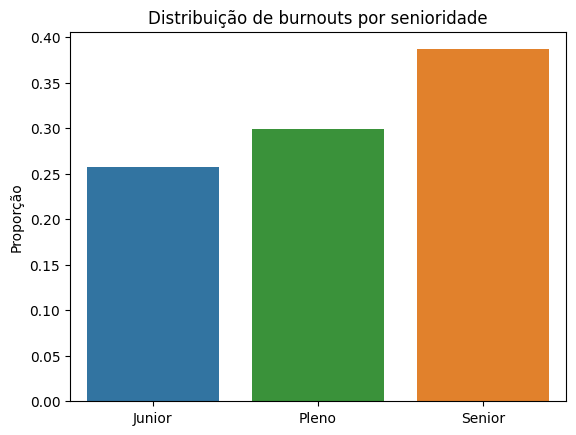

In [ ]:
# Criação do plot de frequência de burnout por senioridade
sns.barplot(
    x='senioridade',
    y='burnout_label',
    data=df,
    order=['Junior', 'Pleno', 'Senior'],
    errorbar=None,
    hue='senioridade'
)
plt.title('Distribuição de burnouts por senioridade') # Título
plt.xlabel('')
plt.ylabel('Proporção') # Legenda
plt.show()

Podemos ver que as ocorrências de _burnout_ crescem com a senioridade, com um pequeno acréscimo de Júnior para Pleno e um acréscimo maior de Pleno para Sênior.

Uma boa hipótese seria o aumento de responsabilidades.

Agora as distribuições das variáveis numéricas para casos de _burnout_ e sem _burnout_.

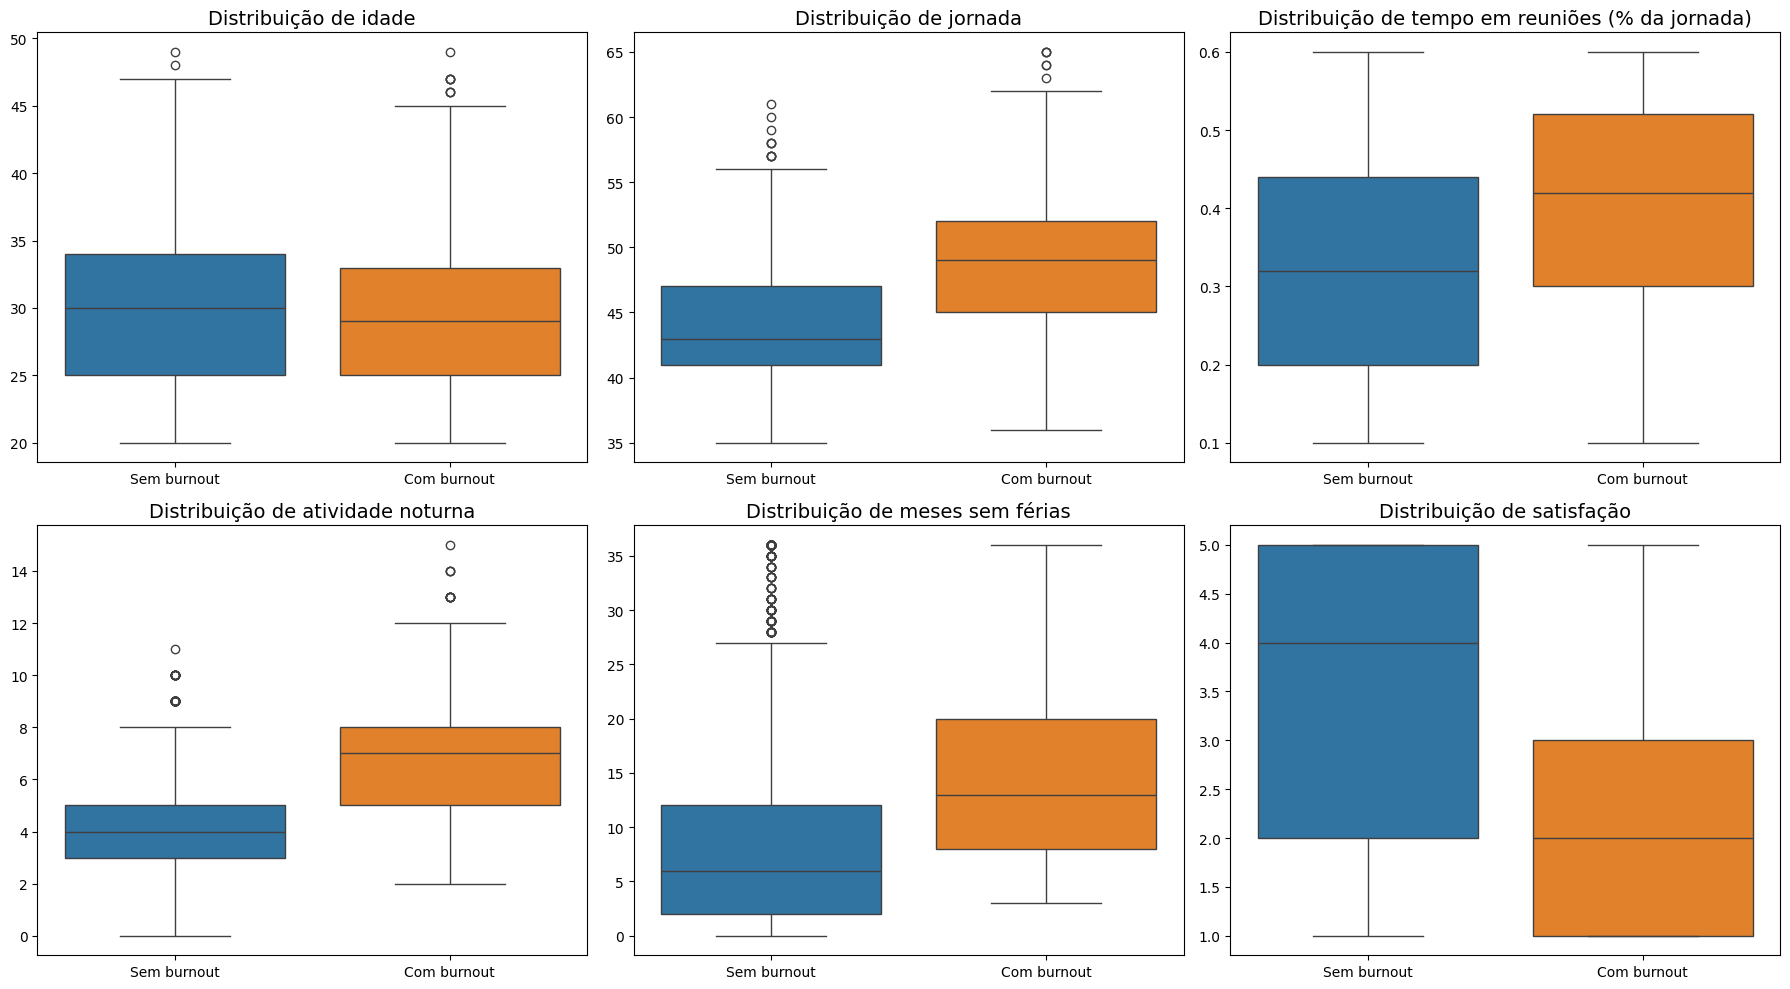

In [ ]:
# Identificar as colunas numéricas para nomeá-las nos boxplots
numeric_cols = df.drop(columns=['senioridade', 'burnout_label']).columns
# Nome mais adequado para cada coluna
numeric_cols_names = ['idade', 'jornada', 'tempo em reuniões (% da jornada)', 'atividade noturna', 'meses sem férias', 'satisfação']
# Criar a figura e os eixos (subplots) 2 linhas, 3 colunas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# Converter o array de eixos de 2D para 1D
axes = axes.flatten()

# Iterar sobre as colunas numéricas e os eixos ao mesmo tempo para desenhar os boxplots
for i, (col_name, proper_name) in enumerate(zip(numeric_cols, numeric_cols_names)):
    sns.boxplot(
        data=df,
        x='burnout_label',
        y=col_name,
        ax=axes[i],
        hue='burnout_label',
        legend=None
    )
    axes[i].set_title(f'Distribuição de {proper_name}', fontsize=14) # Título
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Sem burnout', 'Com burnout']) # Legenda

plt.tight_layout() # Ajuste do plot

Vemos que não há _outliers_ de fato (valores absurdamente discrepantes).

Além disso, tivemos alguns _insights_:

- A idade não parece ter relação com o _burnout_.
- Parece haver uma leve relação entre jornada de trabalho e incidência de burnout.
- Apesar das distribuições de tempo em reunião com _burnout_ e sem serem completamente sobrepostas, há uma diferença evidente entre elas: o intervalo interquartílico (50% dos dados) das duas têm um claro desvio, com o "com _burnout_" deslocado pra cima, ou seja, parece haver relação, pelo menos leve, entre passar mais tempo em reunião e ter _burnout_.
- Parece haver clara relação entre trabalhar fora do expediente e ter _burnout_.
- O mesmo para mais meses sem férias.
- Com relação à satisfação declarada dos funcionários, a diferença é a mais evidente: enquanto a satisfação dos funcionários sem _burnout_ é distribuída mais largamente entre as notas, com maior frequência em 4, o intervalo interquartílico da distribuição da satisfação dos funcionários com _burnout_ é mais estreito, claramente deslocado para baixo e com maior frequência em 2.

Mas há algo estranho. A relação entre jornada de trabalho e _burnout_ não deveria ser alta, intuitivamente falando?

Vamos checar, vendo se há relação mais forte com quem trabalha mais que 40 horas do que quem não.

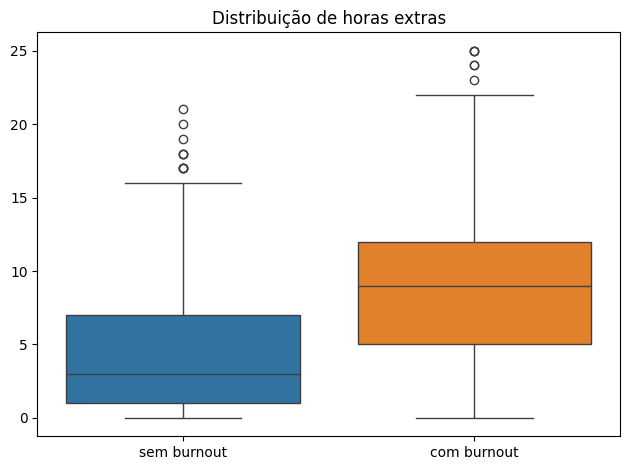

In [ ]:
# Criação da feature horas_extras
# Hora extra é o que excede 40
df['horas_extras'] = (df['horas_trabalho'] - 40).clip(lower=0)

# Criação do boxplot
ax = sns.boxplot(
        data=df,
        x='burnout_label',
        y='horas_extras',
        hue='burnout_label',
        legend=None
)

ax.set_title(f'Distribuição de horas extras') # Título
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([0, 1])
ax.set_xticklabels(['sem burnout', 'com burnout']) # Legenda

plt.tight_layout() # Ajuste do plot

Não parece ser o caso. Talvez a quantidade de pessoas que trabalha 40 horas ou menos é pequena.

Vamos averiguar:

In [ ]:
# Quantos trabalharam 40h ou menos
workers_under_40h = len(df[df['horas_extras'] == 0]) # Contagem de quantos não tiveram horas extras
print(f"Número de funcionários que trabalharam 40h ou menos: {workers_under_40h} ({(workers_under_40h * 100 / len(df)):.2f}%)")

Número de funcionários que trabalharam 40h ou menos: 853 (17.06%)


De fato, a quantidade de funcionários que trabalharam 40h ou menos é pequena: 17%. Por isso, é possível concluir que a quantidade de horas extras e a jornada total semanal têm forte correlação, tornando as horas extras uma métrica redundante ou irrelevante.

---

Agora, vamos fazer uma checagem final de redundância de variável por meio de uma matriz de correlação.

Mas antes, vamos antecipar um passo da parte _feature engineering_ convertendo a coluna de senioridade em valores ordinais: 0 para Junior, 1 para Pleno, 2 para Senior. Isso é possível, pois há um senso de importância (Junior < Pleno < Senior), sentido (Junior vira Pleno, Pleno vira Senior) e distância (Senior é mais distante de Junior do que de Pleno).

Precisamos também eliminar a coluna `horas_extras` criada, já que descobrimos sua irrelevância.

### Correlação:

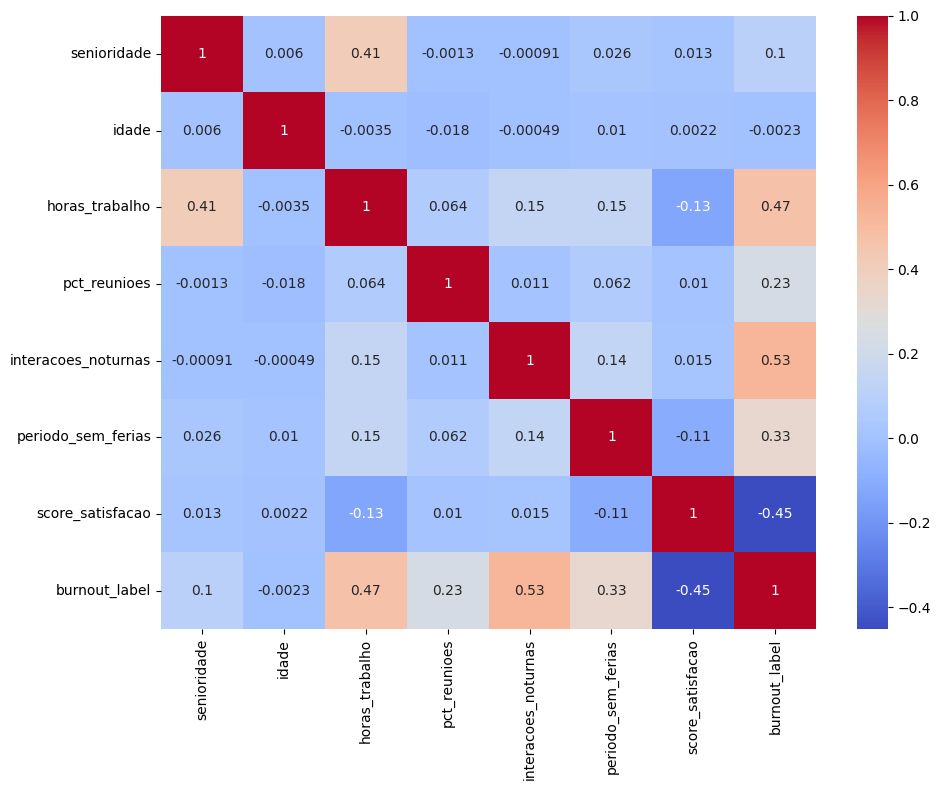

In [ ]:
# Tirando a coluna de horas extras
df = df.drop(columns=['horas_extras'])

# Convertendo senioridade para valores ordinais
# Primeiro, um mapa de conversão
seniority_mapping = {'Junior': 0, 'Pleno': 1, 'Senior': 2}
# Conversão
df['senioridade'] = df['senioridade'].map(seniority_mapping)

# Criação da matriz de correlação
corr_matrix = df.corr()
# Criação da figura
plt.figure(figsize=(10, 8))
# Plotagem da matriz
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# Ajuste do plot
plt.tight_layout()

Aqui, confirmamos a irrelevância da idade para o _burnout_.

Mas acabamos descobrindo que a senioridade não é tão relevantes quanto o gráfico fez parecer, tendo uma correlação pífia de 0,1.

Confirmamos também a significância relativamente forte de _burnout_ com jornada de trabalho, atividade fora de expediente e satisfação do funcionário com o clima da empresa.

---

Por fim, para concluir a exploração, vamos tentar identificar a existência de linearidade entre as variáveis, a fim de termos uma pista de qual tipo de modelo é mais relevante para o caso e sabermos melhor por onde começar.

Para isso vamos usar uma matriz de scatterplots das variáveis.

Vamos também tirar idade e senioridade para descongestionar a análise, com respaldo de que a correlação apontou quase nenhuma influência no _burnout_.

### Verificação de linearidade:

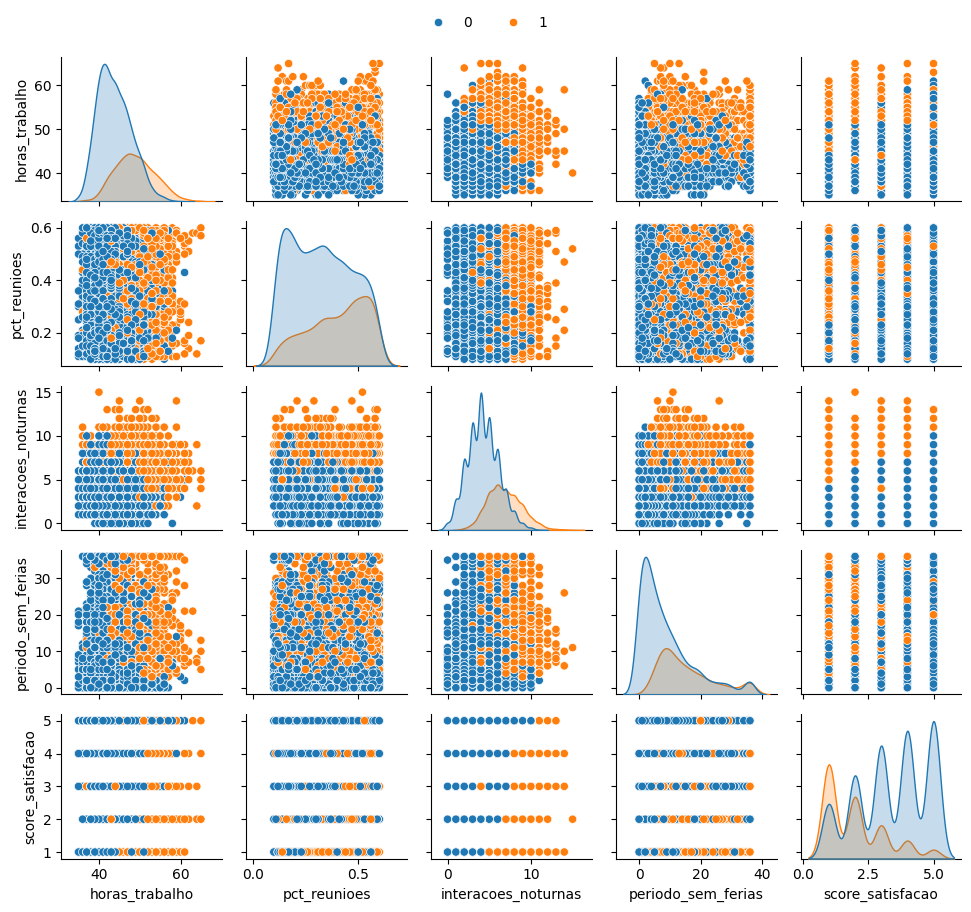

In [ ]:
# Criação do pairplot
g = sns.pairplot(
    df.drop(columns=['senioridade', 'idade']),
    hue='burnout_label',
    height=1.75
)
# Melhor posição para a legenda
sns.move_legend(
    g,
    "lower center",          # Posição de referência da "âncora" da legenda
    bbox_to_anchor=(0.5, 1), # Coordenadas (X, Y). (0.5, 1) = Meio horizontal, Topo vertical
    ncol=2,                  # Define 3 colunas para ficar horizontal
    title=None,              # Remove o título da legenda
    frameon=False,           # Remove a borda da caixa da legenda
)

# Ajustando a fonte para melhor legibilidade
font = 10
for ax in g.axes.flat:
    ax.xaxis.label.set_fontsize(font)
    ax.yaxis.label.set_fontsize(font)

plt.tight_layout() # Ajuste do plot

A matriz de scatterplots das variáveis confirma algumas hipóteses:
- Tempo em reuniões e tempo sem férias têm alguma influência, mas pouca.
- Jornada de trabalho e atividade fora de expediente tem forte influência.

Foi possível ver que o índice de satisfação dos funcionários é ainda mais influente do que imaginamos.

Mas a conclusão principal, e objetivo dessa análise em específico, foi que há uma clara relação linear entre as variáveis: as variáveis influentes no _burnout_ se separam entre si com linhas retas.

Ou seja, modelos lineares como **Regressão Logística** e **SVM linear** provavelmente brilharão.

# 2 . Modelagem Preditiva 🔮

Agora produziremos os modelos de _machine learning_
1. _Feature engineering_
2. Modelagem

## Importação das bibliotecas

In [ ]:
# Importações das bibliotecas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## _Feature engineering_ (Preparação para treinamento dos modelos)

1. Divisão das _features_ e o _target_
    - Definição de quais colunas são as variáveis independentes (_feature_) e qual é a dependente (_target_)
    - No caso, todas colunas exceto a `burnout_label` é _feature_, e a coluna `burnout_label` é o _target_.
2. Divisão _features_ e _target_ em treino e teste
    - Dividir os _datasets_ dividos no passo anterior em _datasets_ de treino dos modelos (`X_train`,`y_train`) e _datasets_ de teste da performance do treinamento (`X_test`,`y_test`).
    - A divisão é aleatória (`random_state=42`) e 70% treino e 30% teste (`test_size=0.3`)
3. Normalização
    - Todas variáveis precisam ser colocadas na mesma escala, ou seja, normalizadas em um padrão único.
    - Aqui usamos o StandardScaler, que transforma o _dataset_, por coluna, em um conjunto de valores cuja média é 0 e o desvio padrão 1.
    - Definido o _scaler_, ele é aplicado nos conjuntos de treinamento e teste das _features_.

In [ ]:
# 1. Definição de features e target
X = df.drop(columns=['burnout_label'])
y = df['burnout_label']

# Divisão do dataset em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Aplicando normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelagem

Agora vamos para a produção dos modelos.

Serão produzidos 7 modelos:
- Regressão Logística
- K _nearest neighbors_
- _Support Vector Machine_
  - Linear
  - Polinomial
  - RBF
- Árvore de Decisão
- Floresta Aleatória

In [ ]:
# Criação dos modelos
log_reg     = LogisticRegression(random_state=42)
knn         = KNeighborsClassifier(n_neighbors=5)
svm_linear  = SVC(kernel='linear', random_state=42)
svm_poly    = SVC(kernel='poly', random_state=42)
svm_rbf     = SVC(kernel='rbf', random_state=42)
dec_tree    = DecisionTreeClassifier(random_state=42)
rand_forest = RandomForestClassifier(random_state=42)

# Treino
log_reg.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)
svm_linear.fit(X_train_scaled, y_train)
svm_poly.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)
dec_tree.fit(X_train_scaled, y_train)
rand_forest.fit(X_train_scaled, y_train)

# Predições
y_pred_log_reg     = log_reg.predict(X_test_scaled)
y_pred_knn         = knn.predict(X_test_scaled)
y_pred_svm_linear  = svm_linear.predict(X_test_scaled)
y_pred_svm_poly    = svm_poly.predict(X_test_scaled)
y_pred_svm_rbf     = svm_rbf.predict(X_test_scaled)
y_pred_dec_tree    = dec_tree.predict(X_test_scaled)
y_pred_rand_forest = rand_forest.predict(X_test_scaled)

target_names = ['Sem burnout', 'Com burnout'] # Nomes dos labels

Com os conjuntos de predições em mãos, podemos ir para análise de resultados e comparação de desempenhos.

# 3 . Resultado Final e Visualização ✨📈

## Relatório de desempenho dos modelos

Primeiro, averiguamos o resultado de cada modelo.

Vemos as 3 métricas clássicas de performance (precisão, _recall_, f1 score) para cada _label_, suas médias (aritmética e ponderada) e a acurávia.

Devido à natureza do problema em questão (identificar pessoas com risco de terem um problema de saúde — _burnout_) o _recall_ é de longe a métrica mais importante: é muito mais impactante não abordar uma pessoa prestes a ter um _burnout_ do que abordar alguém que está bem. Se o RH não abordar uma pessoa prestes a ter um _burnout_, além do prejuízo à saúde do funcionário, a empresa perde esse funcionário até a sua recuperação, enquanto abordar um funcionário que está bem é só um mal entendido.

Vamos às métricas:

Performance do modelo: Regressão Logística
              precision    recall  f1-score   support

 Sem burnout       1.00      1.00      1.00      1053
 Com burnout       1.00      1.00      1.00       447

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



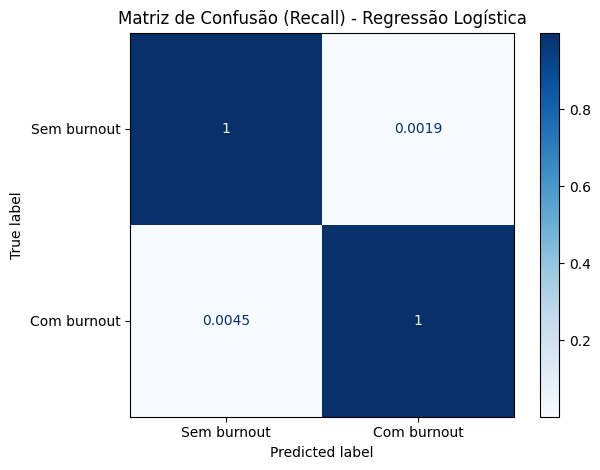

Performance do modelo: KNN
              precision    recall  f1-score   support

 Sem burnout       0.98      0.99      0.98      1053
 Com burnout       0.97      0.94      0.95       447

    accuracy                           0.97      1500
   macro avg       0.97      0.96      0.97      1500
weighted avg       0.97      0.97      0.97      1500



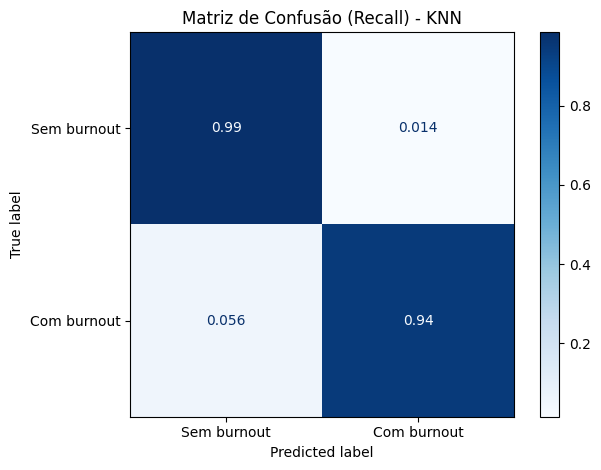

Performance do modelo: SVM Linear
              precision    recall  f1-score   support

 Sem burnout       1.00      1.00      1.00      1053
 Com burnout       1.00      0.99      1.00       447

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



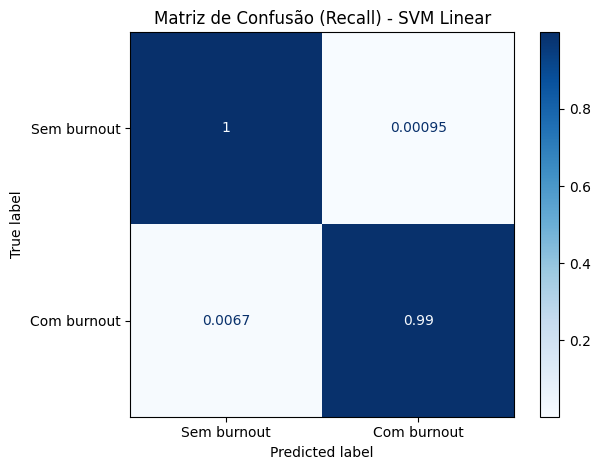

Performance do modelo: SVM Poly
              precision    recall  f1-score   support

 Sem burnout       0.97      0.99      0.98      1053
 Com burnout       0.97      0.93      0.95       447

    accuracy                           0.97      1500
   macro avg       0.97      0.96      0.97      1500
weighted avg       0.97      0.97      0.97      1500



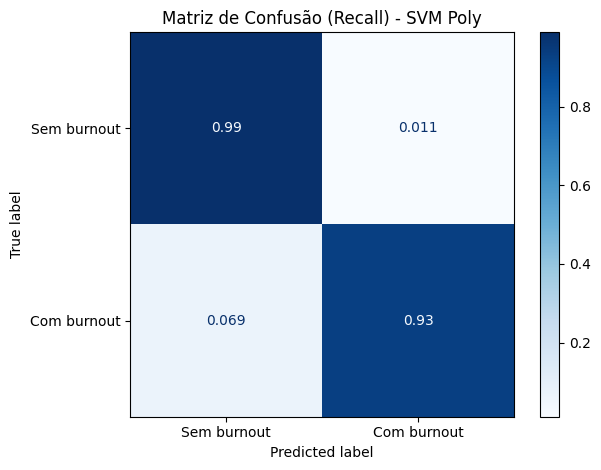

Performance do modelo: SVM RBF
              precision    recall  f1-score   support

 Sem burnout       0.99      1.00      1.00      1053
 Com burnout       0.99      0.99      0.99       447

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



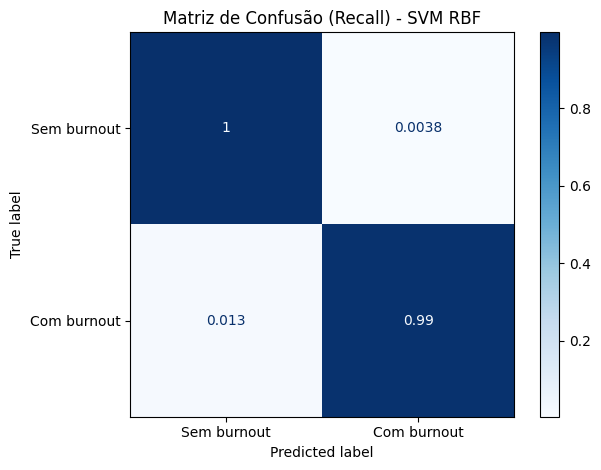

Performance do modelo: Árvore de Decisão
              precision    recall  f1-score   support

 Sem burnout       0.97      0.97      0.97      1053
 Com burnout       0.92      0.93      0.93       447

    accuracy                           0.96      1500
   macro avg       0.95      0.95      0.95      1500
weighted avg       0.96      0.96      0.96      1500



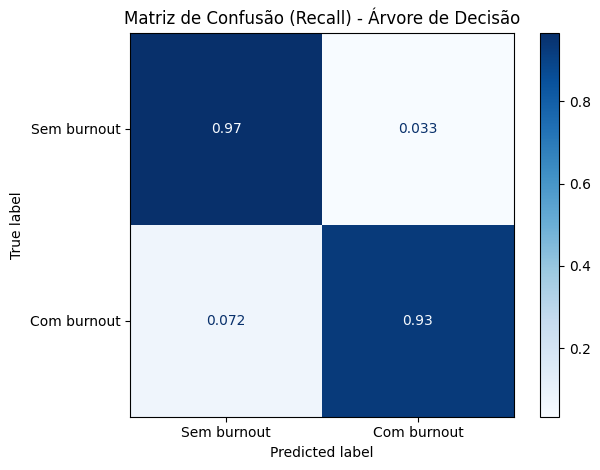

Performance do modelo: Floresta Aleatória
              precision    recall  f1-score   support

 Sem burnout       0.98      0.99      0.99      1053
 Com burnout       0.98      0.95      0.97       447

    accuracy                           0.98      1500
   macro avg       0.98      0.97      0.98      1500
weighted avg       0.98      0.98      0.98      1500



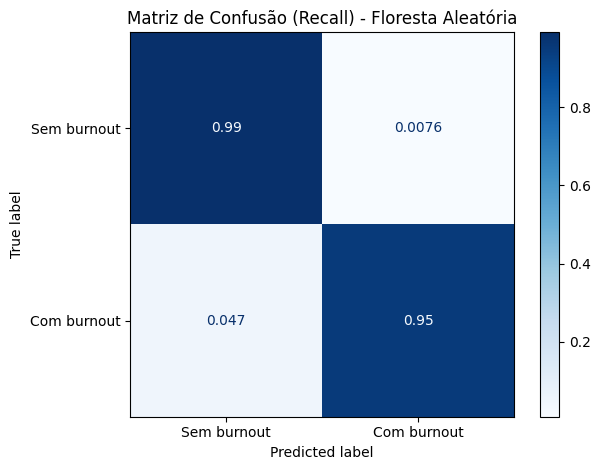

In [ ]:
# Métricas de performance de cada modelo
# Começando mapeando cada conjunto de predições com o nome de seu modelo
modelos = {
    "Regressão Logística": y_pred_log_reg,
    "KNN": y_pred_knn,
    "SVM Linear": y_pred_svm_linear,
    "SVM Poly": y_pred_svm_poly,
    "SVM RBF": y_pred_svm_rbf,
    "Árvore de Decisão": y_pred_dec_tree,
    "Floresta Aleatória": y_pred_rand_forest
}
# Laço para printar relatório de classificação e matriz de confusão de forma prática
for nome, ypred in modelos.items():
    print(f"Performance do modelo: {nome}")
    # Relatório de performance
    print(classification_report(y_test, ypred, target_names=target_names))
    # Matriz de confusão (Recall)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        ypred,
        display_labels=target_names,
        normalize='true',
        cmap='Blues'
    )
    plt.title(f"Matriz de Confusão (Recall) - {nome}") # Título
    plt.tight_layout() # Ajuste do plot
    plt.show()



## Comparativo das métricas dos modelos

Agora vamos à comparação dos modelos usando um gráfico de barras das métricas, agrupadas por modelo, com destaque ao _recall_, que é a métrica mais importante.

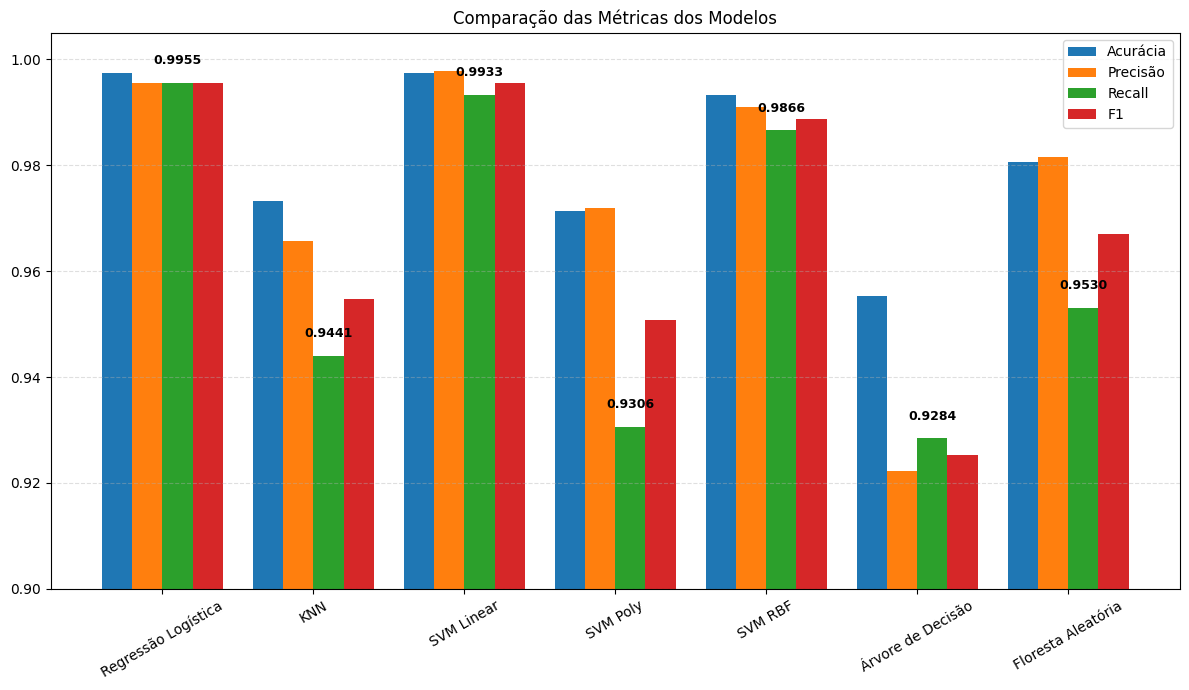

In [ ]:
import numpy as np

metric_names = ["Acurácia", "Precisão", "Recall", "F1"] # Métricas
model_scores = {} # Dicionário onde ficarão as métricas

# Produção das métricas
for nome, ypred in modelos.items():
    acc = accuracy_score(y_test, ypred)
    prec = precision_score(y_test, ypred)
    rec = recall_score(y_test, ypred)
    f1 = f1_score(y_test, ypred)
    model_scores[nome] = [acc, prec, rec, f1]

models = list(model_scores.keys()) # Lista dos nomes dos modelos
# ↓ Transformação da lista de listas dos valores das métricas em uma matriz numpy.
# Usando uma matriz numpy é possível simplificar e encurtar o código por conta
# da integração nativa do matplotlib com o numpy, de forma que não é necessário
# chamar a função de plot diversas vezes, mas apenas uma vez, passando um array
# como parâmetro.
scores = np.array(list(model_scores.values()))
x = np.arange(len(models)) # Quantidade de modelos
width = 0.2 # Largura das barras

fig, ax = plt.subplots(figsize=(12, 7)) # Criação do plot e definição de seu tamanho
for i, metric in enumerate(metric_names):
    ax.bar(x + i*width, scores[:, i], width, label=metric) # Plotagem

for j, nome_modelo in enumerate(models): # Escrevendo o valor do recall
    valor_recall = scores[j, 2]   # 2 = índice do Recall
    posicao_x = x[j] + 2*width    # 2*width porque o Recall é a terceira barra (i=2)
    # Posicionamento do texto
    ax.text(posicao_x, valor_recall + 0.003,
            f'{valor_recall:.4f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models, rotation=30) # Legendas do eixo x
ax.set_ylabel('') # Apagando legenda redundante
ax.set_title('Comparação das Métricas dos Modelos')
# ↓ "zoom" do gráfico (no caso, começa em 0.9, para melhorar a leitura)
ax.set_ylim(0.90, 1.005)
ax.grid(True, axis='y', alpha=0.4, linestyle='--') # Grid de fundo
ax.legend() # Legenda das cores
plt.tight_layout() # Ajuste do plot
plt.show()


# 4 . Conclusão

Todos os modelos apresentaram métricas altas (acurácia, precisão, recall e F1), indicando ótimo desempenho geral.

O ranking ficou:
|Modelo                 |Recall    |
|-----------------------|----------|
|**Regressão Logística**|**99,55%**|
|SVM linear             |    99,33%|
|SVM RBF                |    98,66%|
|Floresta Aleatória     |    95,30%|
|KNN                    |    94,41%|
|SVM poly               |    93,06%|
|Árvore de Decisão      |    92,84%|

Com relação ao _recall_ — o mais importante — Regressão Logística, SVM Linear e SVM RBF foram os destaques, com a **Regressão Logística sendo a campeã**, até em linha com a hipótese inicial da Análise Exploratória de que o problema tem natureza linear.

Importante ressaltar que um _dataset_ real pode ter variáveis não lineares, mas nada vai mudar no _pipeline_ deste sistema preditivo, apenas as performances dos modelos vão ser outras e o novo melhor modelo vai poder ser identificado no fim, na parte de visualização dos resultados.

E considerando que este sistema é um _Proof of Concept_, ou seja, uma base que prova que o conceito — prever _burnout_ iminente — é válido e possível, quando for colocado em produção precisará antes de alguns ajustes finos, como a definição do _threshold_ ótimo do conjunto de probabilidades da previsão por meio de análise do gráfico de precisão x _recall_, por exemplo, depois de treinar em um _dataset_ real.

A metodologia por trás da coleta de dados reais respeitando-se a privacidade dos funcionários está descrita no documento que aponta para este _notebook_.

# LINKS

* **Link do Repositório GitHub (PRIVADO):** [Clique aqui](https://github.com/matguifra/global-solutions-2025.2)
* **Link do Vídeo Integrador (YouTube - Não Listado):** [COLE A URL COMPLETA DO VÍDEO AQUI]
